In [1]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
from random import shuffle
from circularplots import *

np.random.seed(42)
eps = 1e-8

# use Arial
try: 
    font_path = '/home/emil/.fonts/ARIAL.TTF'  # Your font path goes here
    font_manager.fontManager.addfont(font_path)
    prop = font_manager.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = prop.get_name()
except:
    print('Arial font not found, using default')

# global figure size settings
figscale = 2/3
figsize = (4.5* figscale, 2 * figscale)

# plotting colors
colors = [(r/0xff, g/0xff, b/0xff) for r,g,b in [(0x67, 0x19, 0x70), (0xee, 0x96, 0x4b), 
 (0xb6,0xd0, 0x94), (0x66, 0x00, 0x00), (0xab, 0x81, 0xcd), (0x00, 0x6d, 0x6f),
 (0xe5, 0x62, 0x5e), (0xba, 0xde, 0xfc), (0x87, 0x8e, 0x99), (0x29, 0x70, 0x45),
 (0xff, 0xbf, 0xa0)]]

# working directory
wd = os.path.abspath(os.getcwd()).removesuffix('Code/panGenomeAnalysis')
fig_dir = wd + 'Figures/'

In [2]:
df = pd.read_csv(f'{wd}Data/analysis/panGenomeAnalysis/demand_threshold_sensitivity/sensitivityData.csv')
print()
print('All models under all thresholds contain all reactions that have genetic suport:', (df['nRxnsDiscarded'] == 0).all())
print('This many models violate that maximum demand production under both phototrophic\n'
      'and heterotrophic conditions should be at least the threshold:',
      (~((df['photoProdRatio'] + eps >= df['threshold']) & (df['photoProdRatio'] + eps >= df['threshold']))).sum())
print('These are excluded.')
df = df.loc[(df['photoProdRatio'] + eps >= df['threshold']) & (df['photoProdRatio'] + eps >= df['threshold']), :]
df


All models under all thresholds contain all reactions that have genetic suport: True
This many models violate that maximum demand production under both phototrophic
and heterotrophic conditions should be at least the threshold: 4
These are excluded.


,threshold,species,nRxns,nRxnsWithSupport,nRxnsWithoutSupport,nRxnsDiscarded,photoProdRatio,heteroProdRatio
0,0.0,Zingiber_officinale,1246,846,400,0,-0.0,-0.0
1,0.0,Zea_mays,1185,784,401,0,-0.0,-0.0
2,0.0,Vitis_riparia,1252,855,397,0,-0.0,-0.0
3,0.0,Triticum_aestivum,1295,897,398,0,-0.0,-0.0
4,0.0,Tripterygium_wilfordii,1199,801,398,0,-0.0,-0.0
...,...,...,...,...,...,...,...,...
402,1.0,Benincasa_hispida,1243,733,510,0,1.0,1.0
403,1.0,Asparagus_officinalis,1211,673,538,0,1.0,1.0
404,1.0,Arabidopsis_thaliana,1720,1318,402,0,1.0,1.0
405,1.0,Adiantum_capillus-veneris,1136,571,565,0,1.0,1.0


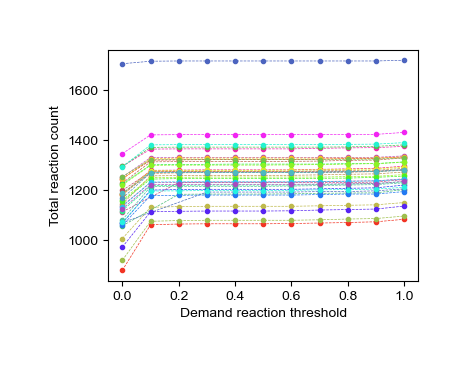

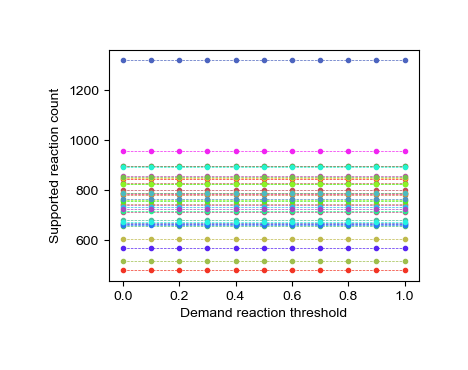

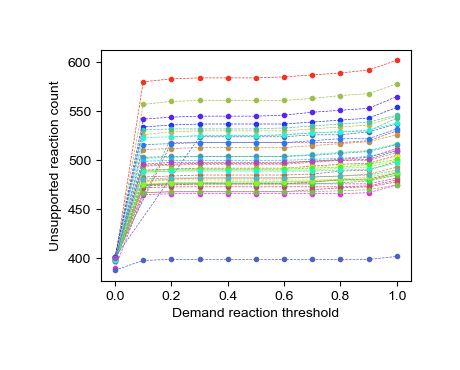

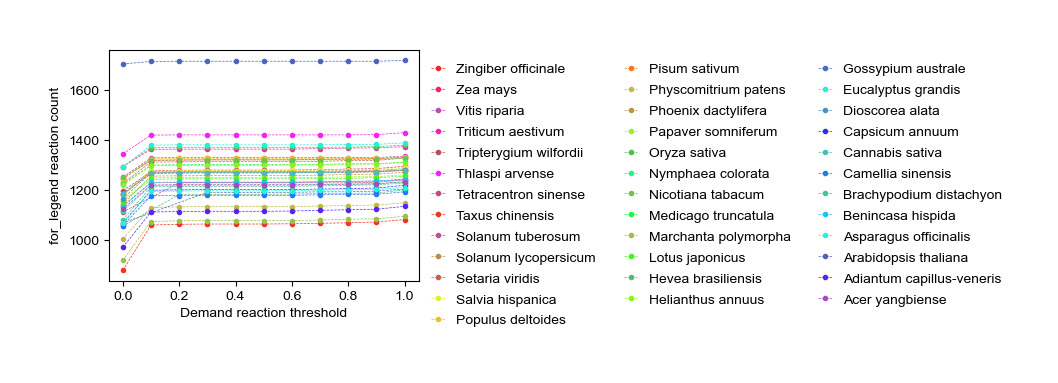

In [3]:
vals_to_plot = [('Total', 'nRxns'), ('Supported', 'nRxnsWithSupport'),
                ('Unsupported', 'nRxnsWithoutSupport'), ('for_legend', 'nRxns')]
contrasting_palette = [
    # Red & Pink Variations
    "#F22424", "#F22469", "#BF4CB0", "#F224AE", "#BF4C5B", 
    "#F124F2", "#BF4C81", "#F23424", "#BF4CA7",
    
    # Orange & Yellow Variations
    "#BF8A4C", "#BF644C", "#E1F224", "#F2BE24", "#F27924", 
    "#BFBA4C", "#BF934C",
    
    # Green Variations
    "#9CF224", "#51BF4C", "#24F28A", "#77BF4C", "#24F246", 
    "#9EBF4C", "#47F224", "#4CBF77", "#8CF224",
    
    # Blue & Cyan Variations
    "#4C6DBF", "#24F2CF", "#4C94BF", "#2435F2", "#4CBABF", 
    "#247AF2", "#4CBF9D", "#24BFF2", "#24F2E0", "#4C64BF",
    
    # Purple & Violet Variations
    "#5724F2", "#A74CBF", "#804CBF", "#5A4CBF", "#AC24F2"
]

for label_str, val in vals_to_plot:
    plt.figure(figsize = (4, 3))
    for species, col in zip(df['species'].unique(), contrasting_palette):
        curr_data = df.loc[df['species'] == species, ['threshold', val]].set_index('threshold')
        plt.plot(curr_data, '--o', label = species.replace('_', ' '), color = col)
    plt.xlabel('Demand reaction threshold')
    plt.ylabel(f'{label_str} reaction count')
    if label_str == 'for_legend':
        plt.legend(ncols = 3, bbox_to_anchor = (1, 1), frameon=False)
    plt.show()

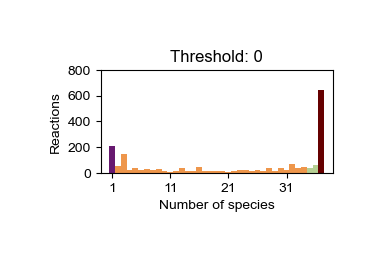

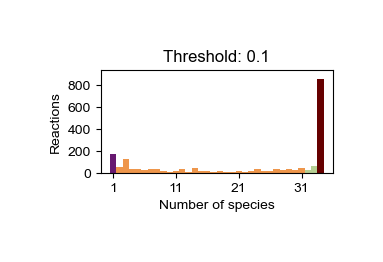

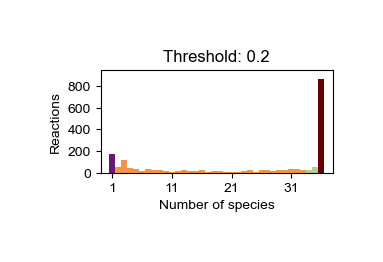

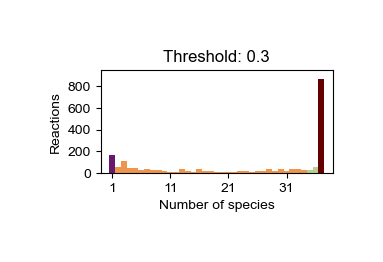

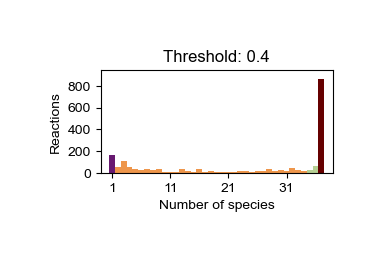

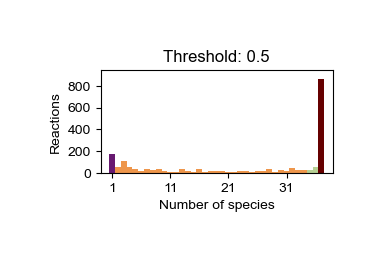

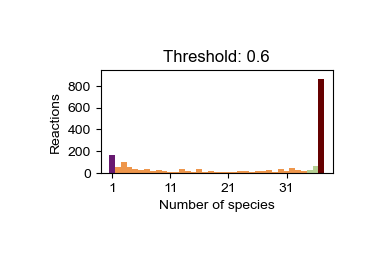

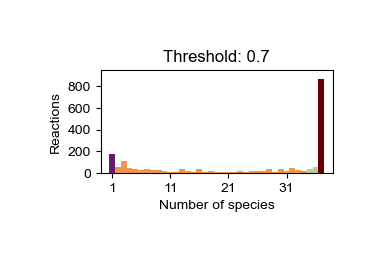

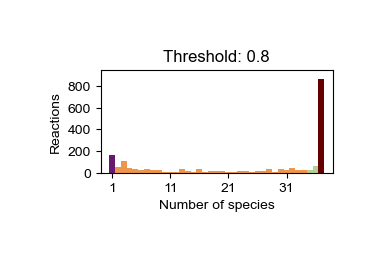

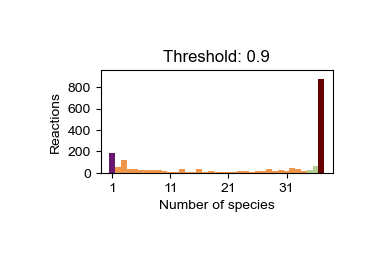

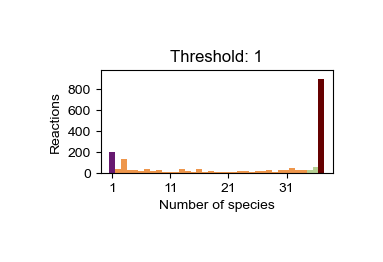

In [ ]:
tot, private, dispensable, softcore, core = [],[],[],[],[]
for t10 in range(11):
    t = t10/10
    if t == int(t):
        t = int(t)

    # read data
    rxn_pav = pd.read_csv(f'{wd}Data/analysis/panGenomeAnalysis/demand_threshold_sensitivity/rxnPav_{t}.csv', index_col=0)
        
    # histogram
    fig, ax = plt.subplots(figsize=figsize)

    range_per_plot = 30

    # get data (in rxn_pav, the first bin is 0 because some rxns are in no model; this cannot happen with genes)
    counts, bins = np.histogram(rxn_pav.mean() * rxn_pav.shape[0], bins = rxn_pav.sum().nunique())
    # exclude that bin because it makes no sense in this framework)
    counts = counts[1:]
    bins = bins[1:]
    poss = np.linspace(1, bins[-1], len(bins) - 1)
    heights = counts
    breakpoint_mid = int(np.ceil(len(counts) * 0.9))
    upper_limit1 = counts.max() * 1.1

    # plot each subplot
    box1 = ax.bar(poss[0], heights[0], width=poss[1]-poss[0], color=colors[0], label='private')
    box2 = ax.bar(poss[1:breakpoint_mid], heights[1:breakpoint_mid], width=poss[1]-poss[0], color=colors[1], label='dispensable')
    box3 = ax.bar(poss[breakpoint_mid:-1], heights[breakpoint_mid:-1], width=poss[1]-poss[0], color=colors[2], label='softcore')
    box4 = ax.bar(poss[-1:], heights[-1:], width=poss[1]-poss[0], color=colors[3], label='core')
    draw_legend = False
    if draw_legend:
        ax.legend(bbox_to_anchor=(0.18, 0.95), frameon=False, 
                handles = [mpl.lines.Line2D([], [], marker = 's', linewidth=0, markersize = 4,
                                            color=box.get_children()[0].get_facecolor())
                                            for box in [box1, box2, box3, box4]],
                labels=[box.get_label() for box in [box1, box2, box3, box4]], 
                handletextpad = 0.4, handleheight = 0.4)
    ax.set_ylim(0, upper_limit1)
    ax.set_xlabel('Number of species')
    ax.set_ylabel('Reactions')
    ax.set_yticks([200 * (i) for i in range(5)])
    xlim = ax.get_xlim()
    ax.set_xticks(ax.get_xticks() + 1)
    ax.set_xlim(poss[0] - 2, poss[-1] + 2)

    ax.set_title(f'Threshold: {t}')

    # output plot
    #plt.savefig(fig_dir + 'panreactome_hist.png', transparent=True, dpi=300, bbox_inches='tight')
    plt.show()

    # and record percentages
    private.append(counts[0])
    dispensable.append(sum(counts[1:breakpoint_mid]))
    softcore.append(sum(counts[breakpoint_mid:-1]))
    core.append(counts[-1])
    tot.append(private[-1] + dispensable[-1] + softcore[-1] + core[-1])


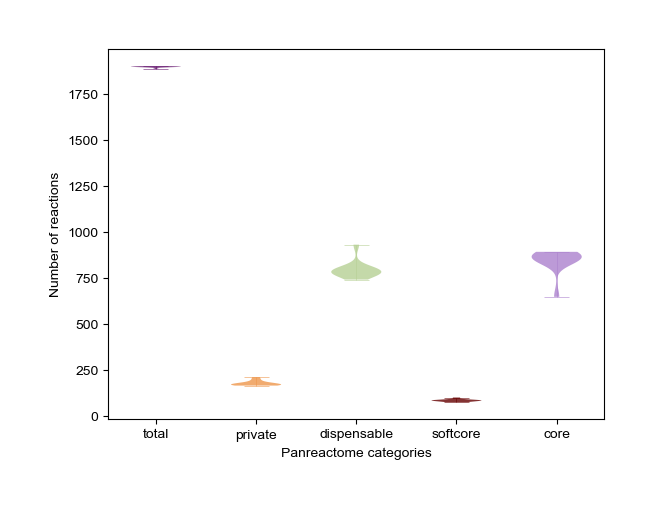

The outlier values in dispensable and core are exclusively t=0


In [28]:
all_data = [tot, private, dispensable, softcore, core]
for i, data in enumerate(all_data):
    vp = plt.violinplot(data, positions=[i])
    vp['bodies'][0].set_facecolor(colors[i])
    vp['bodies'][0].set_alpha(0.8)
    bar_alpha = 0.8
    vp['cbars'].set_color(colors[i])
    vp['cbars'].set_alpha(bar_alpha)
    vp['cmaxes'].set_color(colors[i])
    vp['cmaxes'].set_alpha(bar_alpha)
    vp['cmins'].set_color(colors[i])
    vp['cmins'].set_alpha(bar_alpha)
plt.xticks(list(range(len(all_data))), labels=['total', 'private', 'dispensable', 'softcore', 'core'])
plt.xlabel('Panreactome categories')
plt.ylabel('Number of reactions')

plt.show()
print('The outlier values in dispensable and core are exclusively t=0')

In [26]:
dispensable

[931, 785, 784, 793, 792, 783, 787, 784, 787, 764, 741]

In [27]:
core

[647, 856, 863, 865, 860, 861, 860, 865, 863, 873, 892]